<a href="https://colab.research.google.com/github/AROO-6/Codesoft-Task/blob/main/Movie_Genre_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install nltk scikit-learn pandas matplotlib seaborn wordcloud --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP tools
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Classifiers we'll be comparing
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

# Visualization
from wordcloud import WordCloud

# Download the NLTK data we'll need
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("All imports successful!")

All imports successful!


In [ ]:
# Download the CMU Movie Summary dataset
!wget -q http://www.cs.cmu.edu/~ark/personas/data/MovieSummaries.tar.gz
!tar -xzf MovieSummaries.tar.gz

print("Dataset downloaded and extracted.")

Dataset downloaded and extracted.


In [ ]:
# Load plot summaries
plots_df = pd.read_csv(
    'MovieSummaries/plot_summaries.txt',
    sep='\t',
    header=None,
    names=['movie_id', 'plot']
)

# Load movie metadata (contains genre info)
meta_df = pd.read_csv(
    'MovieSummaries/movie.metadata.tsv',
    sep='\t',
    header=None,
    names=['movie_id','freebase_id','title','release_date',
           'revenue','runtime','languages','countries','genres']
)

print(f"Plots loaded:    {len(plots_df):,}")
print(f"Movies loaded:   {len(meta_df):,}")

Plots loaded:    42,303
Movies loaded:   81,741


In [ ]:
import ast

# The 'genres' column is stored as a JSON-like dict string — let's unpack it
def extract_first_genre(genre_string):
    try:
        genre_dict = ast.literal_eval(genre_string)
        if genre_dict:
            return list(genre_dict.values())[0]   # take the primary genre
    except:
        pass
    return None

meta_df['primary_genre'] = meta_df['genres'].apply(extract_first_genre)

# Merge plots with their genres
data = plots_df.merge(meta_df[['movie_id', 'title', 'primary_genre']], on='movie_id')
data = data.dropna(subset=['plot', 'primary_genre'])

print(f"Combined dataset size: {len(data):,} movies")
data.head()

Combined dataset size: 41,793 movies


,movie_id,plot,title,primary_genre
0,23890098,"Shlykov, a hard-working taxi driver and Lyosha...",Taxi Blues,Drama
1,31186339,The nation of Panem consists of a wealthy Capi...,The Hunger Games,Action/Adventure
2,20663735,Poovalli Induchoodan is sentenced for six yea...,Narasimham,Musical
3,2231378,"The Lemon Drop Kid , a New York City swindler,...",The Lemon Drop Kid,Screwball comedy
4,595909,Seventh-day Adventist Church pastor Michael Ch...,A Cry in the Dark,Crime Fiction


## Step 3 — Explore the Data

Unique genres: 264


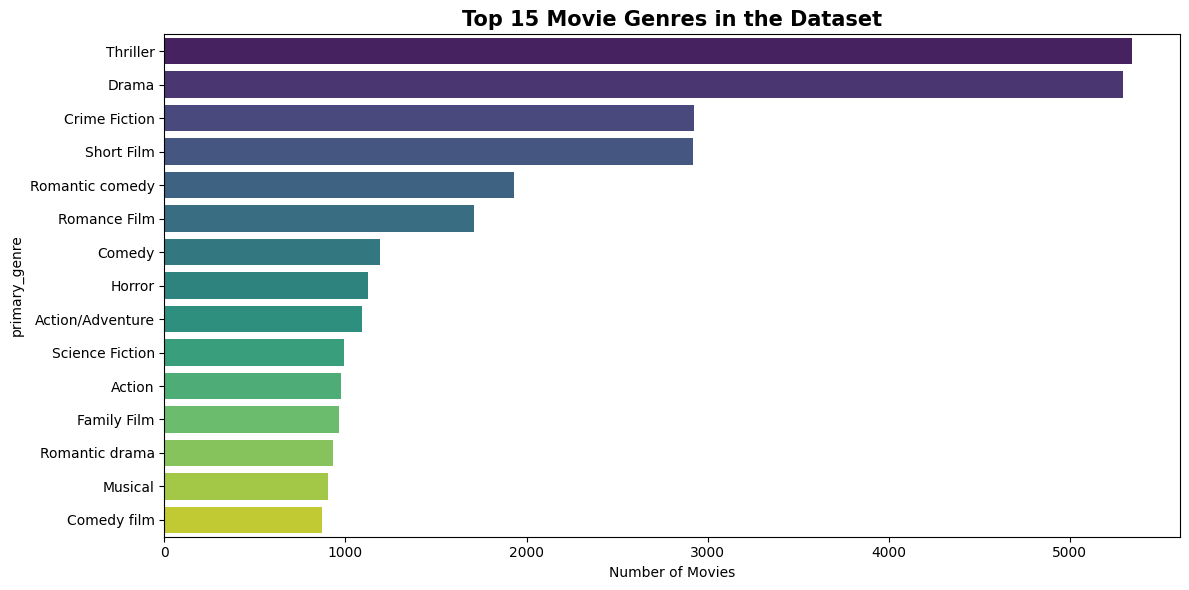

In [ ]:
# How many unique genres do we have?
print(f"Unique genres: {data['primary_genre'].nunique()}")

# Top 15 genres by count
top_genres = data['primary_genre'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 15 Movie Genres in the Dataset', fontsize=15, fontweight='bold')
plt.xlabel('Number of Movies')
plt.tight_layout()
plt.show()

In [ ]:
# Keep only the top N genres so the model has enough data to learn from
TOP_N = 10
top_genre_names = data['primary_genre'].value_counts().head(TOP_N).index.tolist()
data_filtered = data[data['primary_genre'].isin(top_genre_names)].copy()

print(f"Working with top {TOP_N} genres — {len(data_filtered):,} movies total")
print("\nGenre distribution:")
print(data_filtered['primary_genre'].value_counts())

Working with top 10 genres — 24,522 movies total

Genre distribution:
primary_genre
Thriller            5342
Drama               5293
Crime Fiction       2927
Short Film          2920
Romantic comedy     1930
Romance Film        1710
Comedy              1192
Horror              1125
Action/Adventure    1091
Science Fiction      992
Name: count, dtype: int64


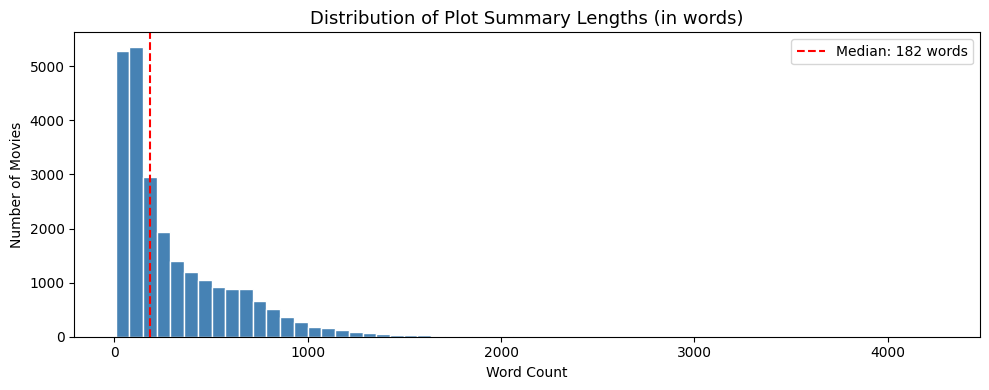

In [ ]:
# Quick look at plot length distribution
data_filtered['plot_length'] = data_filtered['plot'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
plt.hist(data_filtered['plot_length'], bins=60, color='steelblue', edgecolor='white')
plt.title('Distribution of Plot Summary Lengths (in words)', fontsize=13)
plt.xlabel('Word Count')
plt.ylabel('Number of Movies')
plt.axvline(data_filtered['plot_length'].median(), color='red',
            linestyle='--', label=f"Median: {data_filtered['plot_length'].median():.0f} words")
plt.legend()
plt.tight_layout()
plt.show()

## Step 4 — Text Preprocessing

Raw text is messy. We need to clean it up before feeding it to the model.

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase everything
    text = text.lower()

    # Remove things like URLs, emails, numbers, punctuation
    text = re.sub(r'http\S+|www\S+', '', text)       # URLs
    text = re.sub(r'\S+@\S+', '', text)               # emails
    text = re.sub(r'[^a-z\s]', ' ', text)             # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()           # collapse whitespace

    # Tokenize, remove stopwords, and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]

    return ' '.join(tokens)


print("Cleaning plot summaries — this takes a moment...")
data_filtered['clean_plot'] = data_filtered['plot'].apply(clean_text)
print("Done!")

# Before / after example
sample = data_filtered.iloc[0]
print("\n--- BEFORE ---")
print(sample['plot'][:300])
print("\n--- AFTER ---")
print(sample['clean_plot'][:300])

Cleaning plot summaries — this takes a moment...
Done!

--- BEFORE ---
Shlykov, a hard-working taxi driver and Lyosha, a saxophonist, develop a bizarre love-hate relationship, and despite their prejudices, realize they aren't so different after all.

--- AFTER ---
shlykov hard working taxi driver lyosha saxophonist develop bizarre love hate relationship despite prejudice realize different


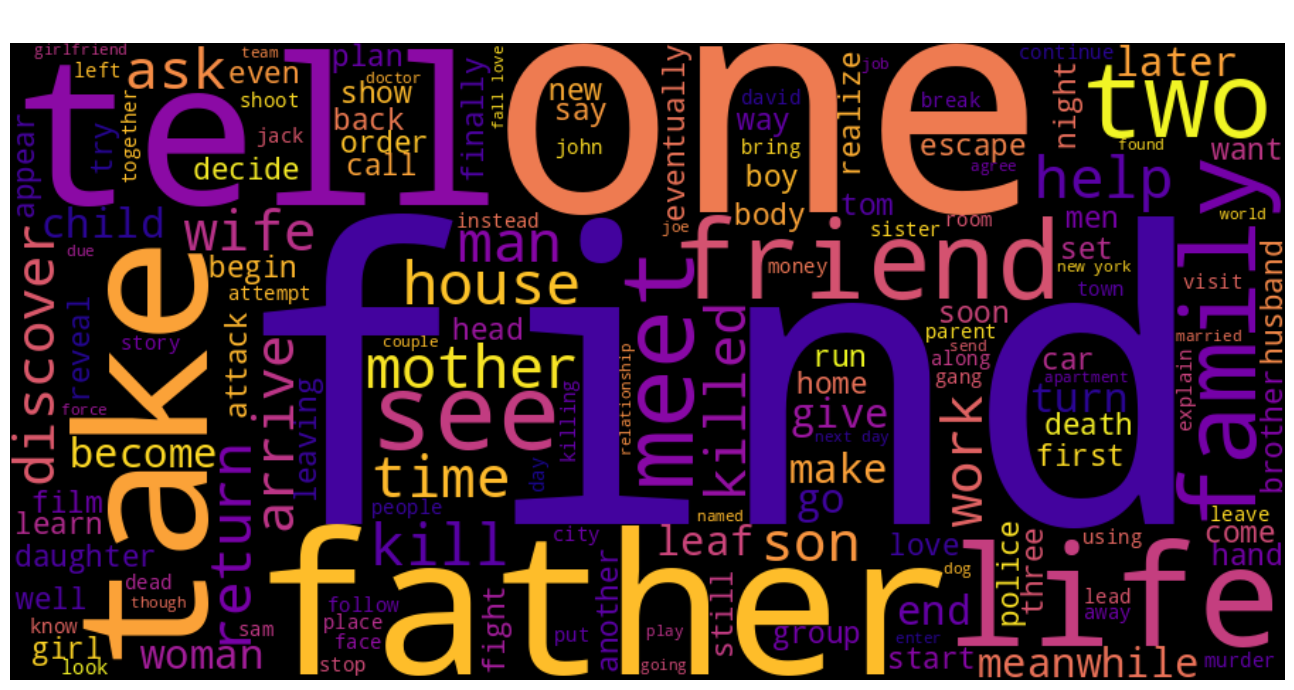

In [ ]:
# Word cloud for the most common words across all genres
all_text = ' '.join(data_filtered['clean_plot'].values)
wc = WordCloud(width=900, height=450, background_color='black',
               colormap='plasma', max_words=150)
wc.generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Movie Plots', fontsize=15, color='white',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## Step 5 — Feature Engineering with TF-IDF

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numbers.
Words that appear often in one plot but rarely across all movies get a high score — those are the words that really characterize a genre.

In [ ]:
# Encode genre labels as integers
le = LabelEncoder()
data_filtered['genre_label'] = le.fit_transform(data_filtered['primary_genre'])

X = data_filtered['clean_plot'].values
y = data_filtered['genre_label'].values

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples:  {len(X_train):,}")
print(f"Test samples:      {len(X_test):,}")

Training samples:  19,617
Test samples:      4,905


In [ ]:
# Build the TF-IDF vectorizer
# max_features=50000 keeps the top 50k most informative words
# ngram_range=(1,2) means we also capture two-word phrases like 'police detective'
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,          # ignore words that appear in fewer than 2 docs
    sublinear_tf=True  # apply log scaling to term frequency
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Feature matrix shape: {X_train_tfidf.shape}")
print(f"(rows = movies, columns = unique words/phrases)")

Feature matrix shape: (19617, 50000)
(rows = movies, columns = unique words/phrases)


## Step 6 — Train & Compare Multiple Classifiers

In [ ]:
# We'll train four classifiers and compare them side by side
classifiers = {
    'Naive Bayes':           MultinomialNB(alpha=0.1),
    'Logistic Regression':   LogisticRegression(max_iter=1000, C=5.0, random_state=42),
    'Linear SVM':            LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

results = {}

for name, clf in classifiers.items():
    print(f"Training {name}...", end=' ')
    clf.fit(X_train_tfidf, y_train)
    preds = clf.predict(X_test_tfidf)

    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')

    results[name] = {'accuracy': acc, 'f1_weighted': f1, 'model': clf, 'preds': preds}
    print(f"Accuracy: {acc:.4f}   F1 (weighted): {f1:.4f}")

print("\nAll classifiers trained!")

Training Naive Bayes... Accuracy: 0.4972   F1 (weighted): 0.4629
Training Logistic Regression... Accuracy: 0.5223   F1 (weighted): 0.5064
Training Linear SVM... Accuracy: 0.5019   F1 (weighted): 0.4899
Training Random Forest... Accuracy: 0.4442   F1 (weighted): 0.3702

All classifiers trained!


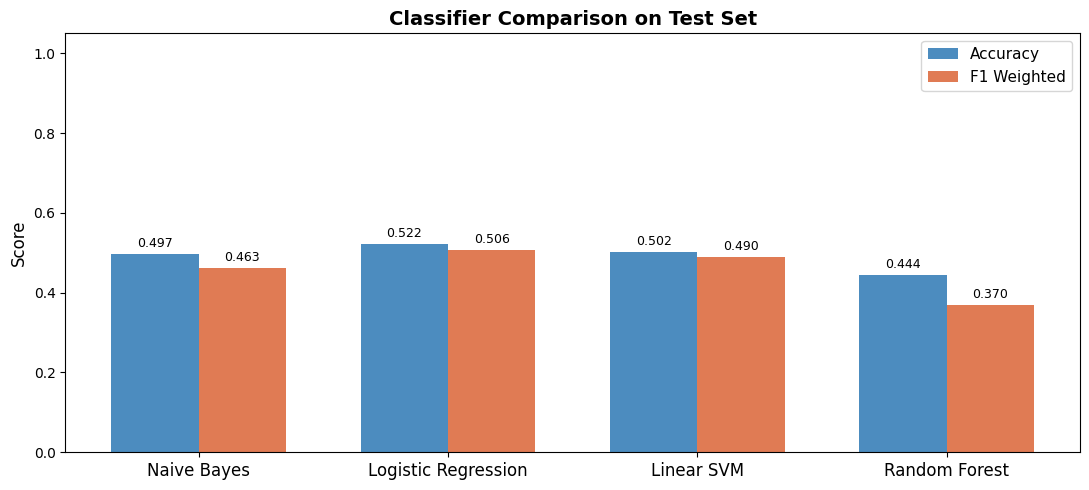

In [ ]:
# Bar chart comparing classifier performance
names  = list(results.keys())
accs   = [results[n]['accuracy']    for n in names]
f1s    = [results[n]['f1_weighted'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, accs, width, label='Accuracy',    color='#4c8cbf')
bars2 = ax.bar(x + width/2, f1s,  width, label='F1 Weighted', color='#e07b54')

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Classifier Comparison on Test Set', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

# Annotate exact scores on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Step 7 — Deep Dive into the Best Model

In [ ]:
# Pick the model with the highest weighted F1 score
best_name = max(results, key=lambda n: results[n]['f1_weighted'])
best_model = results[best_name]['model']
best_preds = results[best_name]['preds']

print(f"Best model: {best_name}")
print(f"Accuracy:   {results[best_name]['accuracy']:.4f}")
print(f"F1 Score:   {results[best_name]['f1_weighted']:.4f}")
print()
print("Full classification report:")
print(classification_report(
    y_test, best_preds,
    target_names=le.classes_
))

Best model: Logistic Regression
Accuracy:   0.5223
F1 Score:   0.5064

Full classification report:
                  precision    recall  f1-score   support

Action/Adventure       0.62      0.32      0.42       218
          Comedy       0.45      0.13      0.20       238
   Crime Fiction       0.44      0.36      0.40       586
           Drama       0.49      0.69      0.57      1059
          Horror       0.52      0.29      0.37       225
    Romance Film       0.38      0.21      0.27       342
 Romantic comedy       0.55      0.52      0.54       386
 Science Fiction       0.56      0.42      0.48       198
      Short Film       0.78      0.71      0.74       584
        Thriller       0.49      0.64      0.55      1069

        accuracy                           0.52      4905
       macro avg       0.53      0.43      0.45      4905
    weighted avg       0.52      0.52      0.51      4905



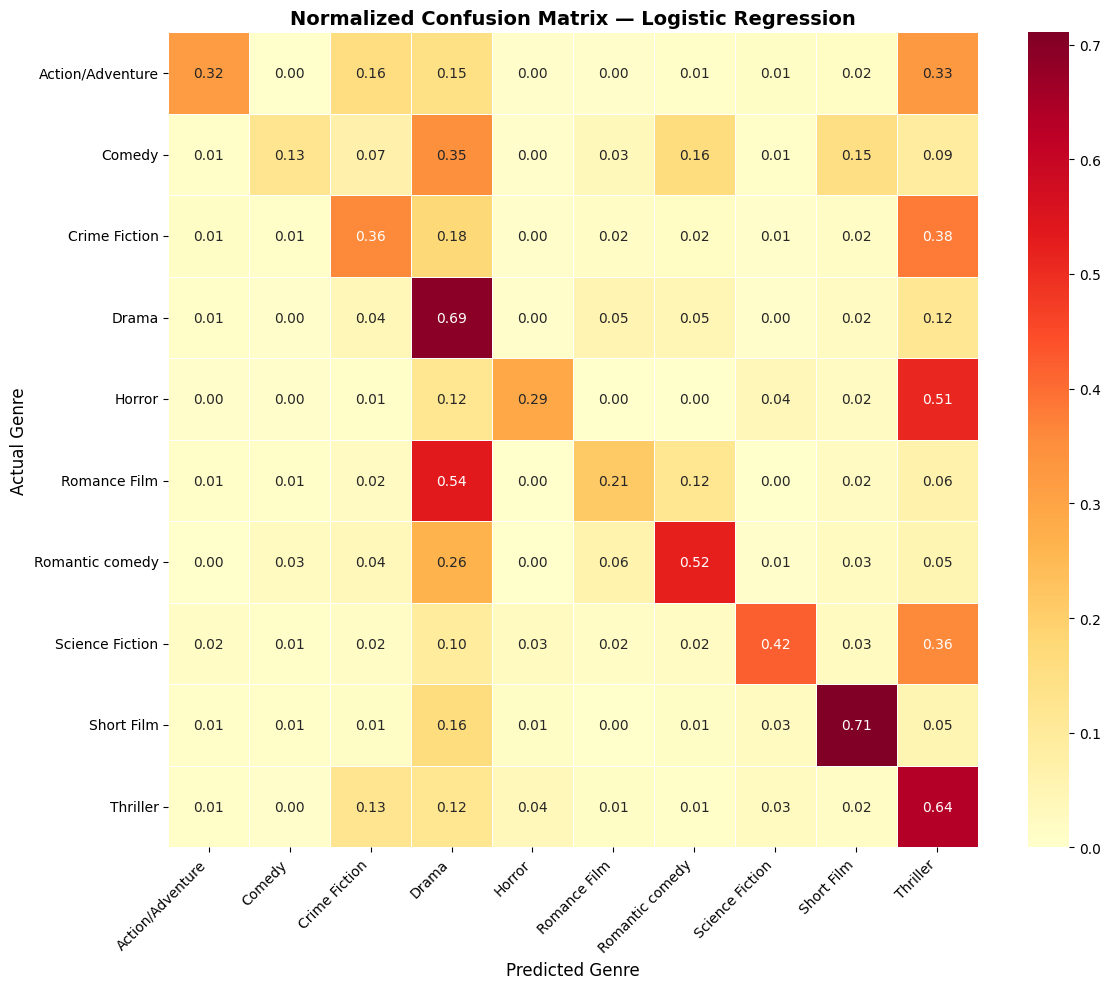

Diagonal cells = correct predictions. Brighter off-diagonal = common misclassifications.


In [ ]:
# Confusion matrix — shows where the model gets confused between genres
cm = confusion_matrix(y_test, best_preds)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalize by row

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.5
)
plt.title(f'Normalized Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Genre', fontsize=12)
plt.ylabel('Actual Genre', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Diagonal cells = correct predictions. Brighter off-diagonal = common misclassifications.")

In [ ]:
# Cross-validation gives a more reliable performance estimate
print(f"Running 5-fold cross-validation on {best_name}...")

cv_scores = cross_val_score(
    best_model,
    tfidf.transform(X),   # use the full dataset for CV
    y,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print(f"CV Accuracy scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

Running 5-fold cross-validation on Logistic Regression...
CV Accuracy scores: [0.5235 0.5101 0.52   0.5226 0.5135]
Mean: 0.5179  |  Std: 0.0053


## Step 8 — What Words Drive Each Genre?

Let's peek inside the Logistic Regression model to see which words it associates most strongly with each genre.

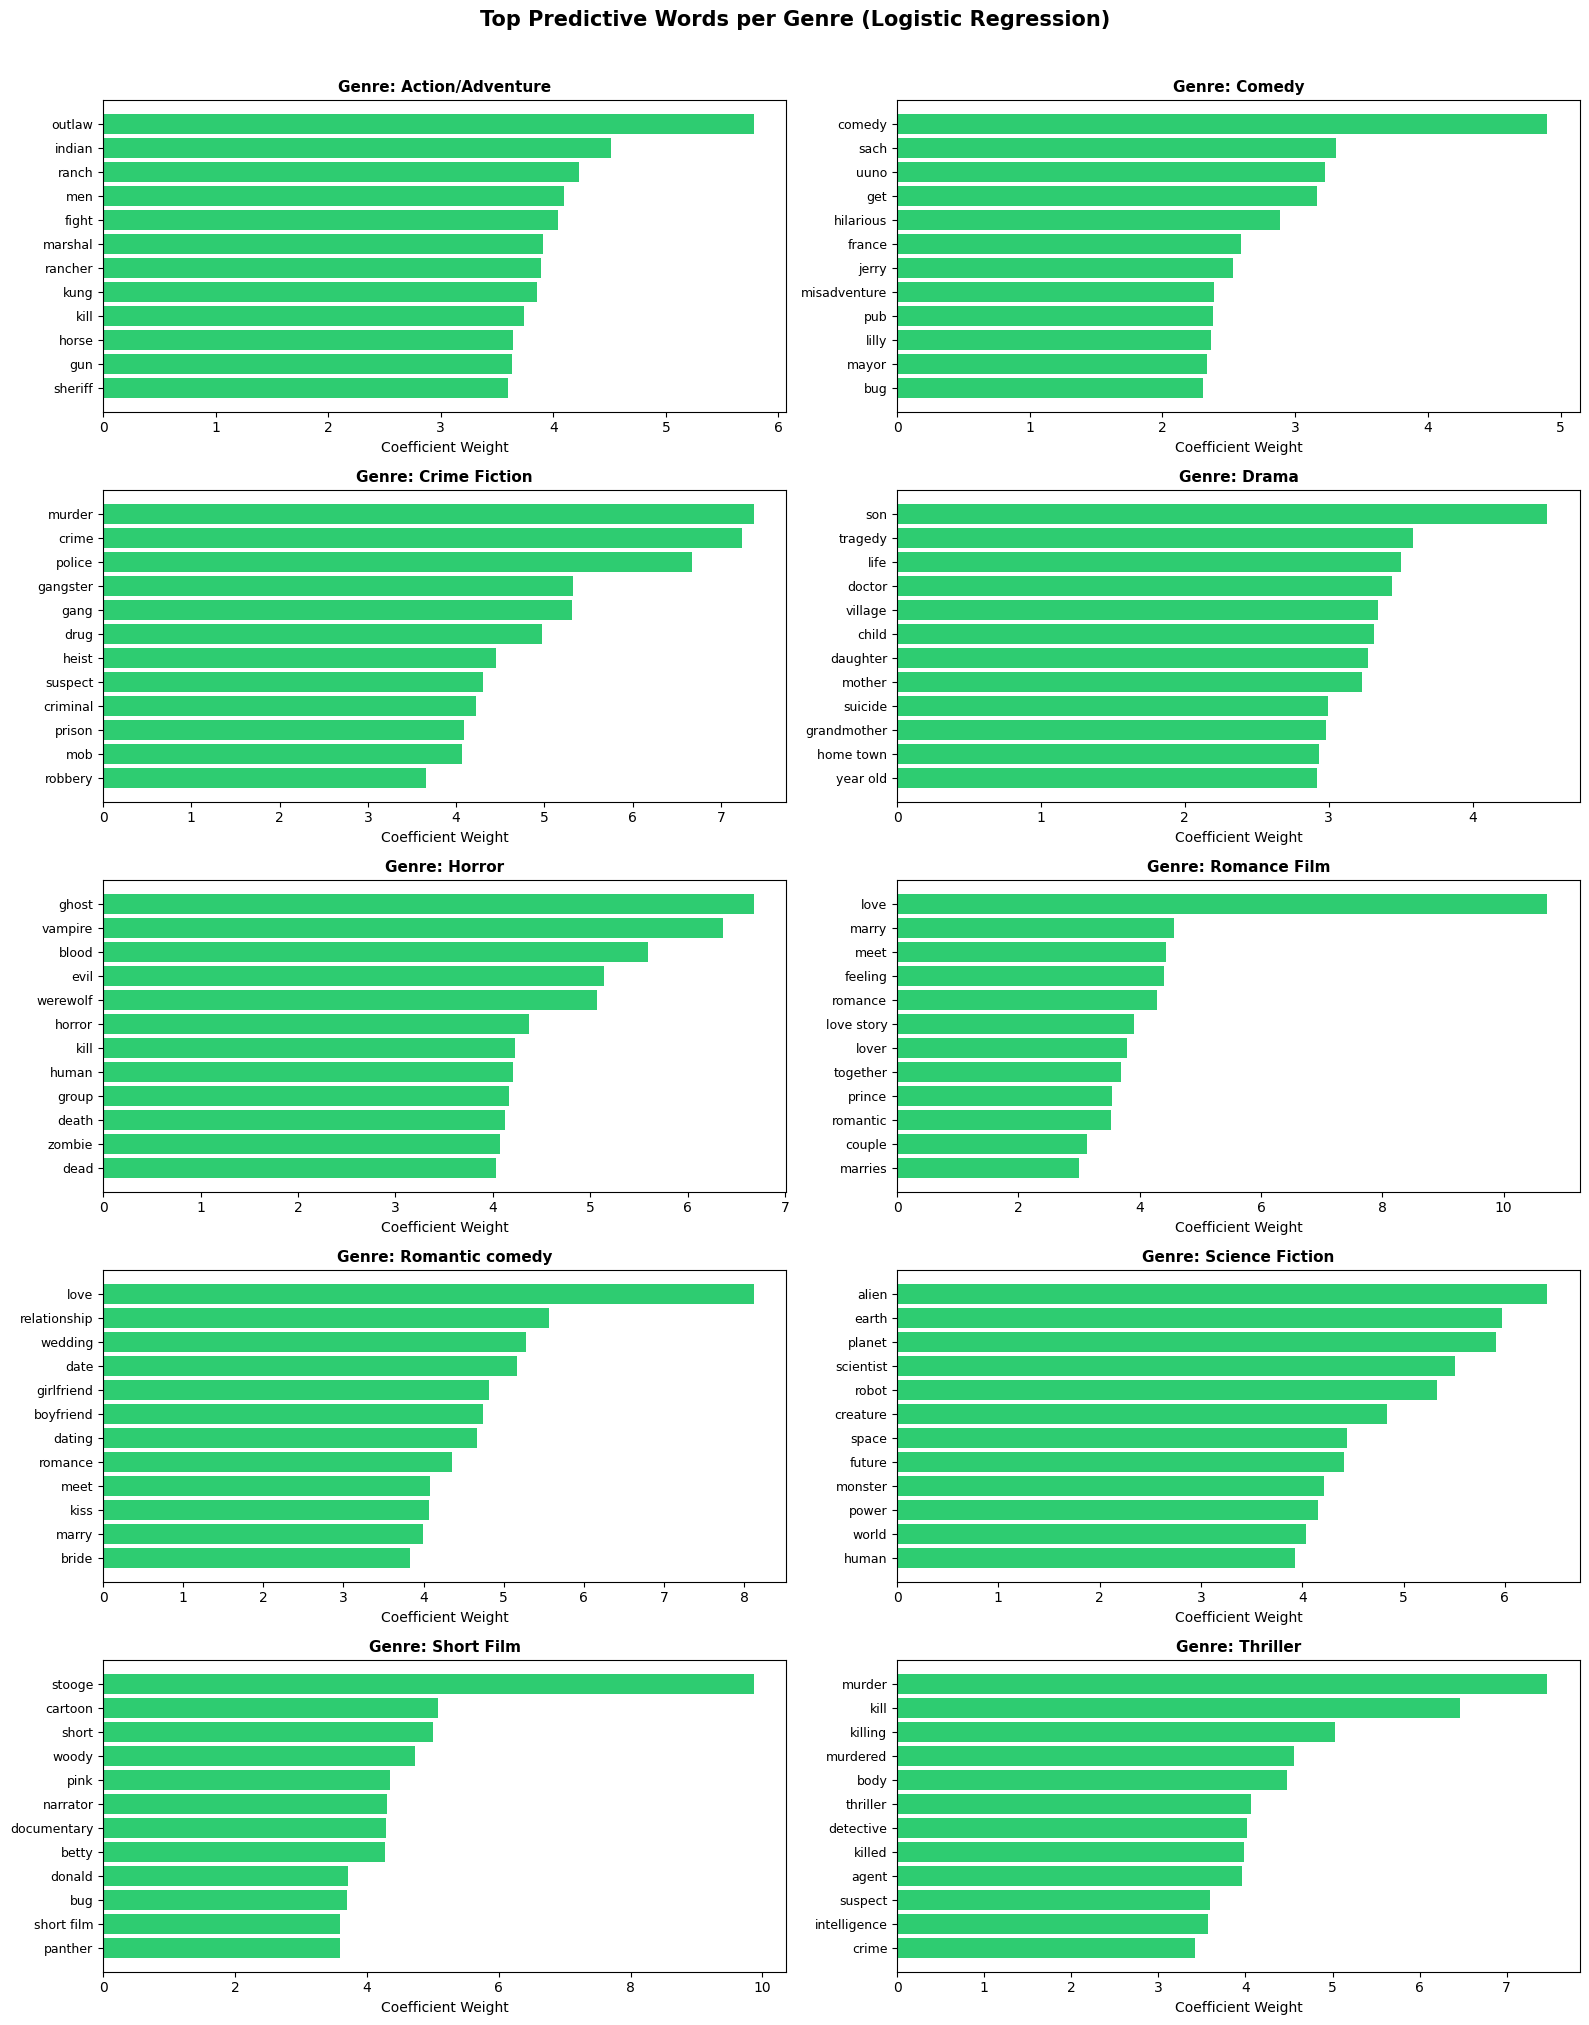

In [ ]:
# This section only works with Logistic Regression (or any linear model with coef_)
lr_model = results['Logistic Regression']['model']
feature_names = np.array(tfidf.get_feature_names_out())

n_top = 12
n_genres = len(le.classes_)
ncols = 2
nrows = (n_genres + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for idx, genre in enumerate(le.classes_):
    coefs = lr_model.coef_[idx]
    top_idx = np.argsort(coefs)[-n_top:][::-1]
    top_words  = feature_names[top_idx]
    top_scores = coefs[top_idx]

    colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in top_scores]
    axes[idx].barh(range(n_top), top_scores[::-1], color=colors[::-1])
    axes[idx].set_yticks(range(n_top))
    axes[idx].set_yticklabels(top_words[::-1], fontsize=9)
    axes[idx].set_title(f'Genre: {genre}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Coefficient Weight')

# Hide any empty subplots
for i in range(n_genres, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Top Predictive Words per Genre (Logistic Regression)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 9 — Save the Best Model

In [ ]:
import joblib

# Save model, vectorizer, and label encoder
joblib.dump(best_model, 'genre_classifier.pkl')
joblib.dump(tfidf,      'tfidf_vectorizer.pkl')
joblib.dump(le,         'label_encoder.pkl')

print("Model saved to disk:")
print("  genre_classifier.pkl")
print("  tfidf_vectorizer.pkl")
print("  label_encoder.pkl")
print()
print("To load later:")
print("  model = joblib.load('genre_classifier.pkl')")
print("  tfidf = joblib.load('tfidf_vectorizer.pkl')")
print("  le    = joblib.load('label_encoder.pkl')")

Model saved to disk:
  genre_classifier.pkl
  tfidf_vectorizer.pkl
  label_encoder.pkl

To load later:
  model = joblib.load('genre_classifier.pkl')
  tfidf = joblib.load('tfidf_vectorizer.pkl')
  le    = joblib.load('label_encoder.pkl')


## Step 10 — Test the Model on New Movie Plots

Let's write a function we can use interactively — paste any plot summary and get a genre prediction with confidence scores.

In [ ]:
def predict_genre(plot_text, top_k=3):
    """
    Given a raw plot summary string, return the predicted genre
    and the top-k most likely genres with their probability scores.
    """
    cleaned = clean_text(plot_text)
    vectorized = tfidf.transform([cleaned])

    predicted_label = best_model.predict(vectorized)[0]
    predicted_genre = le.inverse_transform([predicted_label])[0]

    # If the model supports probability output, show top-k
    top_genres_text = ""
    if hasattr(best_model, 'predict_proba'):
        probs = best_model.predict_proba(vectorized)[0]
        top_idx = np.argsort(probs)[-top_k:][::-1]
        top_genres_text = "\nTop predictions:"
        for i in top_idx:
            top_genres_text += f"\n  {le.inverse_transform([i])[0]:<25} {probs[i]*100:.1f}%"

    print(f"Predicted genre: {predicted_genre}")
    print(top_genres_text)
    return predicted_genre


# --- Test on some example plots ---

example_plots = [
    (
        "A police detective teams up with a reformed thief to track down a "
        "serial killer who leaves cryptic clues at each crime scene. Racing "
        "against the clock, they navigate a city gripped by fear.",
        "Expected: Thriller / Crime"
    ),
    (
        "Two college roommates fall in love during a semester abroad in Paris, "
        "but their relationship is tested when they return home to different cities "
        "and must decide if their love is strong enough to survive the distance.",
        "Expected: Romance / Drama"
    ),
    (
        "A group of astronauts embarks on a desperate mission to save Earth from "
        "an incoming asteroid. Using experimental technology, they travel beyond "
        "the solar system only to discover an alien civilization watching them.",
        "Expected: Science Fiction / Action"
    ),
    (
        "A bumbling magician accidentally summons a talking rabbit who becomes "
        "his sarcastic sidekick. Together they stumble into a carnival competition "
        "where nothing goes as planned.",
        "Expected: Comedy"
    ),
]

for plot, note in example_plots:
    print("=" * 55)
    print(f"Plot: {plot[:80]}...")
    print(f"({note})")
    predict_genre(plot)
    print()

Plot: A police detective teams up with a reformed thief to track down a serial killer ...
(Expected: Thriller / Crime)
Predicted genre: Crime Fiction

Top predictions:
  Crime Fiction             56.8%
  Thriller                  39.1%
  Horror                    1.1%

Plot: Two college roommates fall in love during a semester abroad in Paris, but their ...
(Expected: Romance / Drama)
Predicted genre: Romance Film

Top predictions:
  Romance Film              50.1%
  Romantic comedy           32.3%
  Drama                     11.8%

Plot: A group of astronauts embarks on a desperate mission to save Earth from an incom...
(Expected: Science Fiction / Action)
Predicted genre: Science Fiction

Top predictions:
  Science Fiction           83.7%
  Thriller                  10.2%
  Short Film                1.8%

Plot: A bumbling magician accidentally summons a talking rabbit who becomes his sarcas...
(Expected: Comedy)
Predicted genre: Short Film

Top predictions:
  Short Film              

In [ ]:
# Interactive cell — paste any plot and get a prediction!
my_plot = """
A widowed father discovers his young son has gone missing on a camping trip.
As he searches through the dense forest, he begins to suspect that something
supernatural is preventing anyone from leaving. The townsfolk have a secret
they'll do anything to protect.
"""

print("Your movie plot:")
print(my_plot.strip())
print()
predict_genre(my_plot)

Your movie plot:
A widowed father discovers his young son has gone missing on a camping trip.
As he searches through the dense forest, he begins to suspect that something
supernatural is preventing anyone from leaving. The townsfolk have a secret
they'll do anything to protect.

Predicted genre: Thriller

Top predictions:
  Thriller                  71.2%
  Horror                    10.6%
  Drama                     5.9%


'Thriller'

## Summary

| Step | What we did |
|------|-------------|
| 1 | Installed libraries |
| 2 | Downloaded and loaded the CMU Movie dataset |
| 3 | Explored genre distribution and plot lengths |
| 4 | Cleaned text — lowercasing, stop word removal, lemmatization |
| 5 | TF-IDF vectorization (unigrams + bigrams, 50k features) |
| 6 | Trained 4 classifiers and compared accuracy & F1 |
| 7 | Confusion matrix + cross-validation on best model |
| 8 | Visualized top predictive words per genre |
| 9 | Saved model with `joblib` |
| 10 | Built a reusable prediction function |

**Next steps to improve further:**
- Try word embeddings (Word2Vec, GloVe, FastText) as an alternative to TF-IDF  
- Fine-tune a pre-trained transformer like BERT or DistilBERT  
- Use multi-label classification (a movie can belong to multiple genres)  
- Add more features: movie title, release year, runtime  
- Hyperparameter tuning with `GridSearchCV`  
